# 3.5 — Gradient Descent: watch your code learn

Do the **pen-and-paper worksheet first** — you've already run this algorithm by hand.
Now let the machine take the steps while you watch. By the last cell you will have implemented,
from scratch, the algorithm that trains every neural network on Earth.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

def derivative(f, x, h=1e-6):        # nudge machine — our slope-feeler in the fog
    return (f(x + h) - f(x)) / h

## 1. The whole algorithm

Feel the slope, step downhill, repeat. Note the code never *sees* the whole curve —
it only ever feels the ground underfoot.

In [2]:
def f(x):
    return x**2

x = 4.0
lr = 0.1                              # the learning rate, η
path = [x]                            # keep a diary of everywhere we stand
for step in range(25):
    slope = derivative(f, x)          # feel the ground
    x = x - lr * slope                # THE update rule
    path.append(x)                    # .append adds to the end of a list

print("first few footsteps:", [round(p, 2) for p in path[:5]])   # matches worksheet P5?
print("final position:     ", round(path[-1], 5))                 # [-1] = last item

first few footsteps: [4.0, 3.2, 2.56, 2.05, 1.64]
final position:      0.01511


## 2. Plot the footsteps on the curve

Every stop on the descent, drawn where it happened. Notice the spacing: bold strides on steep
ground, tiptoes near the bottom — nobody programmed that, it falls out of slope × learning rate.

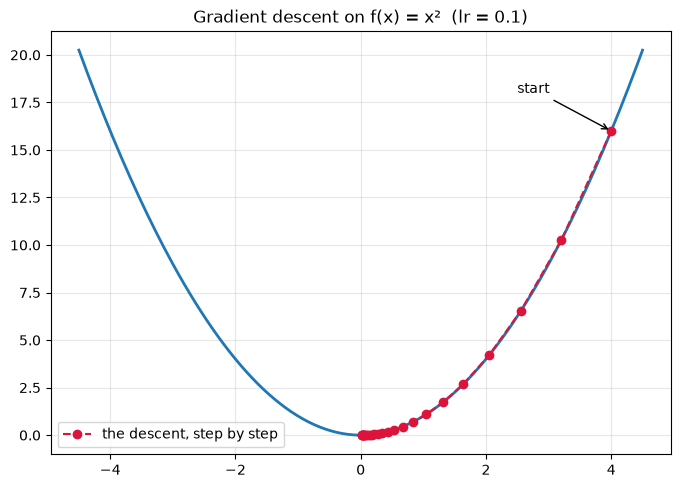

In [3]:
xs = np.linspace(-4.5, 4.5, 200)
path = np.array(path)                 # numpy array so we can do f(path) in one go

plt.figure(figsize=(8, 5.5))
plt.plot(xs, f(xs), linewidth=2)
plt.plot(path, f(path), "o--", color="crimson", markersize=6, label="the descent, step by step")
plt.annotate("start", (path[0], f(path[0])), xytext=(2.5, 18),
             arrowprops=dict(arrowstyle="->"))
plt.grid(alpha=0.3)
plt.legend()
plt.title("Gradient descent on f(x) = x²  (lr = 0.1)")
plt.show()

## 3. The learning-rate experiments

Worksheet Part B, all four runs at once. Same function, same start — only $\eta$ changes:

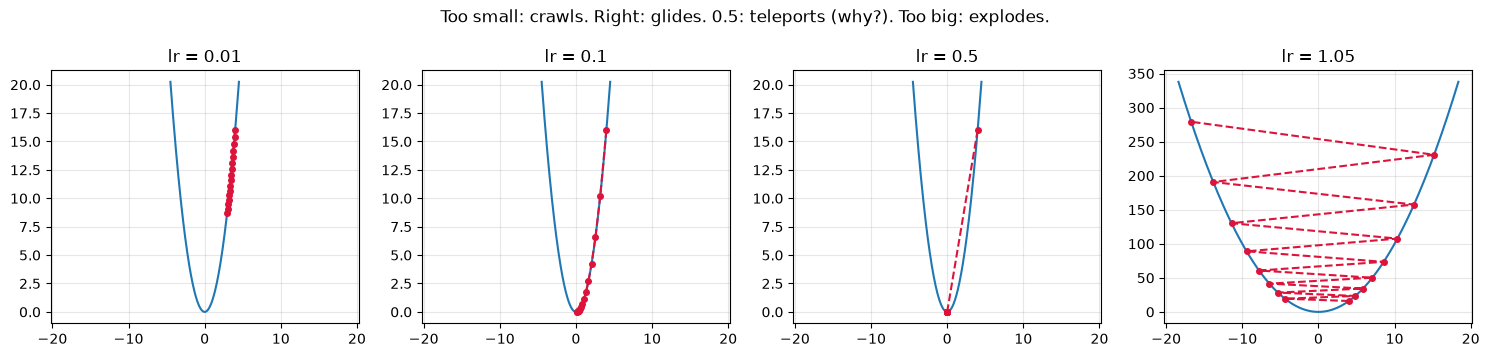

In [4]:
def descend(f, x0, lr, steps=15):
    trail = [x0]
    x = x0
    for _ in range(steps):            # _ means 'we don't need the loop counter'
        x = x - lr * derivative(f, x)
        trail.append(x)
    return np.array(trail)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True)
for ax, lr in zip(axes, [0.01, 0.1, 0.5, 1.05]):
    trail = descend(f, 4.0, lr)
    span = max(4.5, np.abs(trail).max() * 1.1)
    gx = np.linspace(-span, span, 200)
    ax.plot(gx, f(gx), linewidth=1.5)
    ax.plot(trail, f(trail), "o--", color="crimson", markersize=4)
    ax.set_title(f"lr = {lr}")
    ax.grid(alpha=0.3)
fig.suptitle("Too small: crawls. Right: glides. 0.5: teleports (why?). Too big: explodes.")
plt.tight_layout()
plt.show()

In [5]:
# YOUR TURN — a new valley, an unknown terrain.
#   f2(x) = (x - 3)² + 1     (a bowl whose floor is NOT at zero)
# 1. Define f2.
# 2. Descend from x0 = -2. Pick your own lr.
# 3. Print the final position — before running, write your prediction here: ____
# 4. Try to find an lr that converges in under 10 steps without exploding.

def f2(x):
    return 0    # <- fix me

# trail = descend(f2, -2.0, lr=???)
# print(trail[-1])

## 4. 🌀 Two parameters: water finding the valley

Real models have many weights, so let's descend a 2-parameter bowl,
$L(w, b) = (w - 2)^2 + (b + 1)^2$, using one nudge per parameter (lesson 3.4) —
from several random starting points at once. Watch every path curve down the contour map
like rainwater finding the same valley:

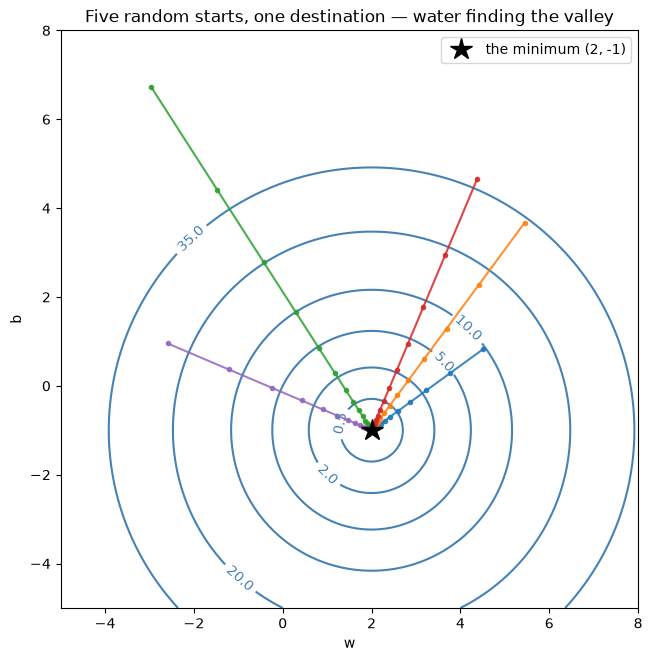

In [6]:
def L(w, b):
    return (w - 2)**2 + (b + 1)**2

def descend_2d(w, b, lr=0.15, steps=30, h=1e-6):
    trail = [(w, b)]
    for _ in range(steps):
        dL_dw = (L(w + h, b) - L(w, b)) / h     # nudge w, freeze b
        dL_db = (L(w, b + h) - L(w, b)) / h     # nudge b, freeze w
        w, b = w - lr * dL_dw, b - lr * dL_db   # step against the gradient
        trail.append((w, b))
    return np.array(trail)

# the terrain
grid = np.linspace(-5, 8, 120)
W, B = np.meshgrid(grid, grid)
plt.figure(figsize=(7.5, 7.5))
cs = plt.contour(W, B, L(W, B), levels=[0.5, 2, 5, 10, 20, 35], colors="steelblue")
plt.clabel(cs)

# five random rain-drops
rng = np.random.default_rng(42)
for _ in range(5):
    w0, b0 = rng.uniform(-4, 7, size=2)
    trail = descend_2d(w0, b0)
    plt.plot(trail[:, 0], trail[:, 1], "o-", markersize=3, alpha=0.85)

plt.plot(2, -1, "k*", markersize=16, label="the minimum (2, -1)")
plt.gca().set_aspect("equal")
plt.legend()
plt.title("Five random starts, one destination — water finding the valley")
plt.xlabel("w"); plt.ylabel("b")
plt.show()

Look at what just happened. Your code was never told where the minimum was. It felt the slope,
stepped downhill, and *learnt* the answer — from anywhere. Replace this toy bowl with a
175-billion-parameter loss surface and this loop, essentially unchanged, is how GPT was trained.
You now own the core of it.

---
*Done? Photograph your worksheet into `scans/inbox/`, then it's boss time:
`worksheets/06-boss-calculus.md`. Beat it and the Random Walks interlude awaits.*